In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Read the data from csv
df_subject = pd.read_csv('subject-info.csv')
df_test = pd.read_csv('test_measure.csv')

#Merge 2 datsets on participant ID
df_merge = pd.merge(df_subject,df_test, on='ID')

In [81]:
#Q17 - Display a histogram showing the distribution of athletes by their BMI values.


def display_histogram(filepath ='subject-info.csv'):
    
    #Read the excel file  
    df = pd.read_csv(filepath)  
    #Convert the Height to meters
    df['Height_meter'] = df['Height']/100
    #BMI=weight(kg)/(height(m))^2
    df['BMI'] = (df['Weight']/(df['Height_meter'] ** 2)).round(1)
    
    #Set the size of Histogram figure, title, color, x,y axis
    plt.figure(figsize=(10, 6))
    plt.hist(df['BMI'], bins=10, color='skyblue', edgecolor='black')
    plt.title('Distribution of Athletes by BMI')
    plt.xlabel('BMI')
    plt.ylabel('Number of Athletes')
    plt.grid(axis='y', alpha=0.4)
    plt.show()
   




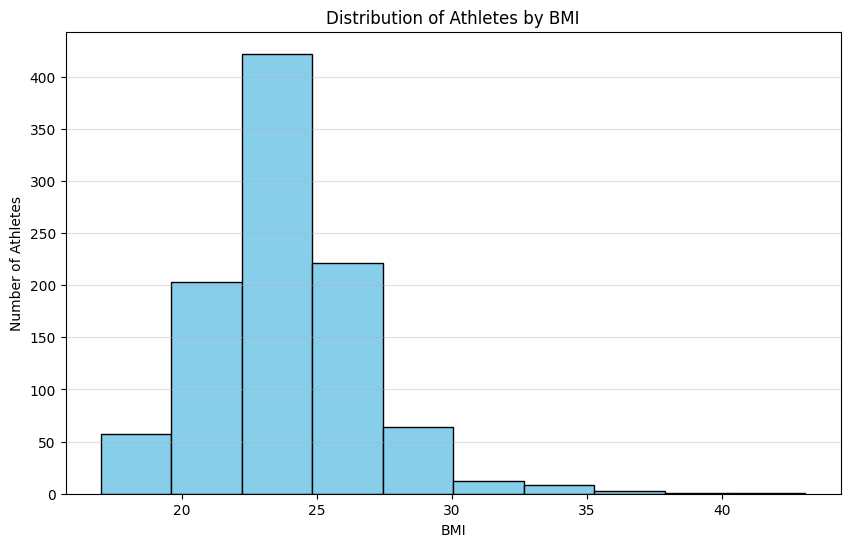

In [82]:
display_histogram()

In [ ]:
#Q18 - Who is the tallest participant in the dataset? What is  his/her Vo2 kg/ml?


#Get the tallest participant's record
tallest_record = df_subject.loc[df_subject['Height'].idxmax()]

#Get the tallest participant's records rom merged dataset
tallest_reocords_merged = df_merge.loc[df_merge['ID']==tallest_record['ID']].copy()

#Get all VO2 record of tallest participant and convert into (ml/kg/min), round to 2 decimal places
tallest_reocords_merged['VO2'] = (tallest_reocords_merged['VO2']/tallest_record['Weight']).apply(lambda x: f"{x:.2f}")


print(f"Tallest Participant ID: {tallest_record['ID']}")
print(f"Tallest Participant Height is: {tallest_record['Height']} ", tallest_record['Height'], "cm" )
print(f"Tallest Participant (ID: {tallest_record['ID']}) VO2(ml/kg/min) Records: ")
display(tallest_reocords_merged[['ID','VO2']].style.hide(axis='index'))



Tallest Participant ID:  94
Tallest Participant Height is:  203.0 cm
Tallest Participant (ID: 94) VO2(ml/kg/min) Records: 


ID,VO2
94,8.64
94,11.54
94,8.60
94,10.06
94,10.53
94,11.01
94,11.59
94,13.01
94,13.02
94,13.83


In [99]:
#Q19 - What is the highest recorded heart rate?Identify the patient with the highest recorded heart rate.

#Get the highest Heart Rate and ID of the participant
highest_heartrate = df_test.loc[df_test['HR'].idxmax(),['ID','HR']]

#Display ID and HR with one decimal place
print("Highest recorded Heart rate and  ID of Participant with highest HR: ")
display(highest_heartrate.to_frame().T.style.hide(axis='index').format({'HR': '{:.1f}'}))



Highest recorded Heart rate and  ID of Participant with highest HR: 


ID,HR
619,226.0


In [133]:
#Q20 - What is the VO2 max(mL/kg/min) of the shortest male athlete?

#Filter the male athlete records
df_male = df_subject[df_subject['Sex']==0]

#Get the male athlete with the shortest Height
shortest_male = df_male.loc[df_male['Height'].idxmin()]


#Get the V02 of the shortest male athlete
shortest_male_VO2 =  df_merge.loc[df_merge['ID']==shortest_male['ID'],'VO2']

#Convert VO2 max to (mL/kg/min)
shortest_male_VO2_max = float(shortest_male_VO2.max()/shortest_male['Weight'])
shortest_male_VO2_max = shortest_male_VO2_max.__round__(2)

print(f"VO2 max(mL/kg/min) of the shortest male athlete is {shortest_male_VO2_max}(mL/kg/min)")



VO2 max(mL/kg/min) of the shortest male athlete is 49.62(mL/kg/min)


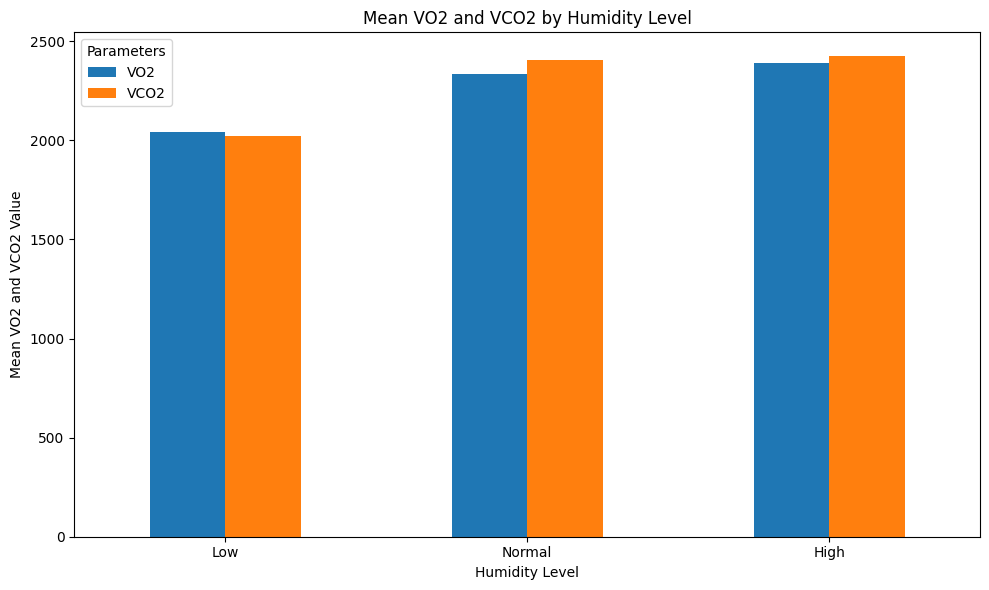

In [21]:
#Q21 - Analyze the mean VO2 and VCO2 values by humidity level using a Multiseries Bar Chart.

df_merge['Humidity_Level'] = pd.cut(df_merge['Humidity'], bins=[0,30,60,float('inf')], labels=['Low', 'Normal', 'High'])

humiditygroup_data = df_merge.groupby(df_merge['Humidity_Level'], observed=False)[['VO2','VCO2']].mean()

humiditygroup_data.plot(kind='bar', figsize=(10, 6))
plt.title('Mean VO2 and VCO2 by Humidity Level')
plt.ylabel('Mean VO2 and VCO2 Value')
plt.xlabel('Humidity Level')
plt.xticks(rotation=0)
plt.legend(title='Parameters')
plt.tight_layout()

plt.show()



Observation for Q.21
Participants exposed to low humidity conditions exhibited reduced mean VO₂ and VCO₂ levels, suggesting a possible correlation between humidity and  VO₂ and VCO₂ levels

In [ ]:
#Q22 - Display the average speed of each participant  in ' peak exercise' based on RER, (Following question no.14)


In [ ]:
#Q23 - Assign one of the following 5 heart rate zones for every Athletes and add this as a column to a new table with all unique IDs. Exclude Warm-Up Phase

#Exclude warm up phase
df_test_excludewarmup =df_test[ df_test['Speed'] > 5]

#Get Max HR for every athlete and name the column as HR_max
athlete_hr_max = df_test_excludewarmup.groupby('ID').agg(HR_max=('HR','max')).reset_index()

#Assign HR Zone
def assign_heartrate_zone(hr_max):
    if hr_max < 100:
        return 'Zone 1 (recovery/easy)'
    elif 100 <= hr_max <= 120:
        return 'Zone 2 (aerobic/base)'
    elif 121 <= hr_max <= 135:
        return 'Zone 3 (tempo)'
    elif 136 <= hr_max <= 155:
        return 'Zone 4 (lactate threshold)'
    else:
        return 'Zone 5 (anaerobic)'

#Apply HR Zone to each athlete based on max HR  
athlete_hr_max['HR Zone'] = athlete_hr_max['HR_max'].apply(assign_heartrate_zone)

#Create a new table with unique athlete ID's and HR Zone
hr_zone = (athlete_hr_max.drop_duplicates('ID')
                  .loc[:, ['ID', 'HR Zone']]
                  
)            
                        
hr_zone.style.hide(axis='index')


ID,HR Zone
1,Zone 5 (anaerobic)
2,Zone 5 (anaerobic)
3,Zone 5 (anaerobic)
4,Zone 5 (anaerobic)
5,Zone 5 (anaerobic)
6,Zone 5 (anaerobic)
7,Zone 5 (anaerobic)
8,Zone 5 (anaerobic)
9,Zone 5 (anaerobic)
10,Zone 5 (anaerobic)


In [ ]:
#Q24 - Find the athlete who has got optimal respiratory stability based on the measure of  Breathing Interval variability over time.

#Calculate duration of a breath in seconds
df_test['BI'] = 60/ df_test['RR']

#Group by athlete and calculate mean and std.deviation
mean_std_bi_athlete = df_test.groupby('ID')['BI'].agg(['mean','std'])

#Calculate Coefficient of Variation (CV) of BI
mean_std_bi_athlete['CV'] = mean_std_bi_athlete['std']/mean_std_bi_athlete['mean']

#Lower CV = more stable breathing.
athlete_respiratory_stability = mean_std_bi_athlete['CV'].idxmin()

print(f"ID of the Athlete who has got optimal respiratory stability is: {athlete_respiratory_stability}")




ID of the Athlete who has got optimal respiratory stability is: 235


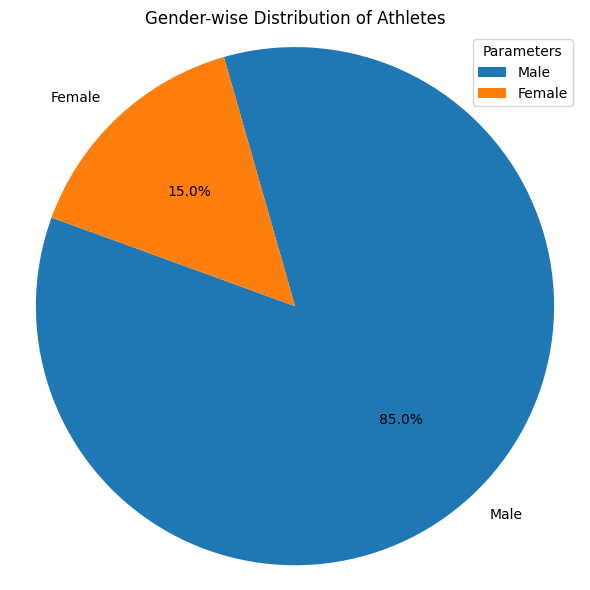

In [74]:
#Q25 - Generate a pie chart to show the gender-wise distribution of athletes.


#Map 0 to Male and 1 to Female
df_subject['gender_label'] = df_subject['Sex'].map({0: 'Male', 1: 'Female'})

#Count the genders
df_gender_count = df_subject['gender_label'].value_counts()
df_gender_count

#Plot Pie chart
plt.figure(figsize=(6, 6))
plt.pie(df_gender_count, labels=df_gender_count.index, autopct='%1.1f%%', startangle=160)
plt.title('Gender-wise Distribution of Athletes')
plt.legend(title='Parameters')
plt.axis('equal')  # Equal aspect ratio ensures a perfect circle.
plt.tight_layout()
plt.show()

In [ ]:
#Q25 - Use enumeration to print ID, Sex, and BMI of each athlete.